In [1]:
# Decision Tree Regressor
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

In [2]:
df = load_diabetes(as_frame=True).frame

In [3]:
X = df.drop("target", axis=1)
y = df["target"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [5]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(max_depth=7, min_samples_leaf=20)
model.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=7, min_samples_leaf=20)

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error

y_pred_train = model.predict(X_train)
y_pred_test= model.predict(X_test)

+.
print("MSE train: ", mean_squared_error(y_train, y_pred_train))
print("MSE test: ", mean_squared_error(y_test, y_pred_test))

print("r^2 train: ", r2_score(y_train, y_pred_train))
print("r^2 test: ", r2_score(y_test, y_pred_test))

MSE train:  2795.7093704335157
MSE test:  3177.664925233041
r^2 train:  0.5452860742356658
r^2 test:  0.41135906558189406


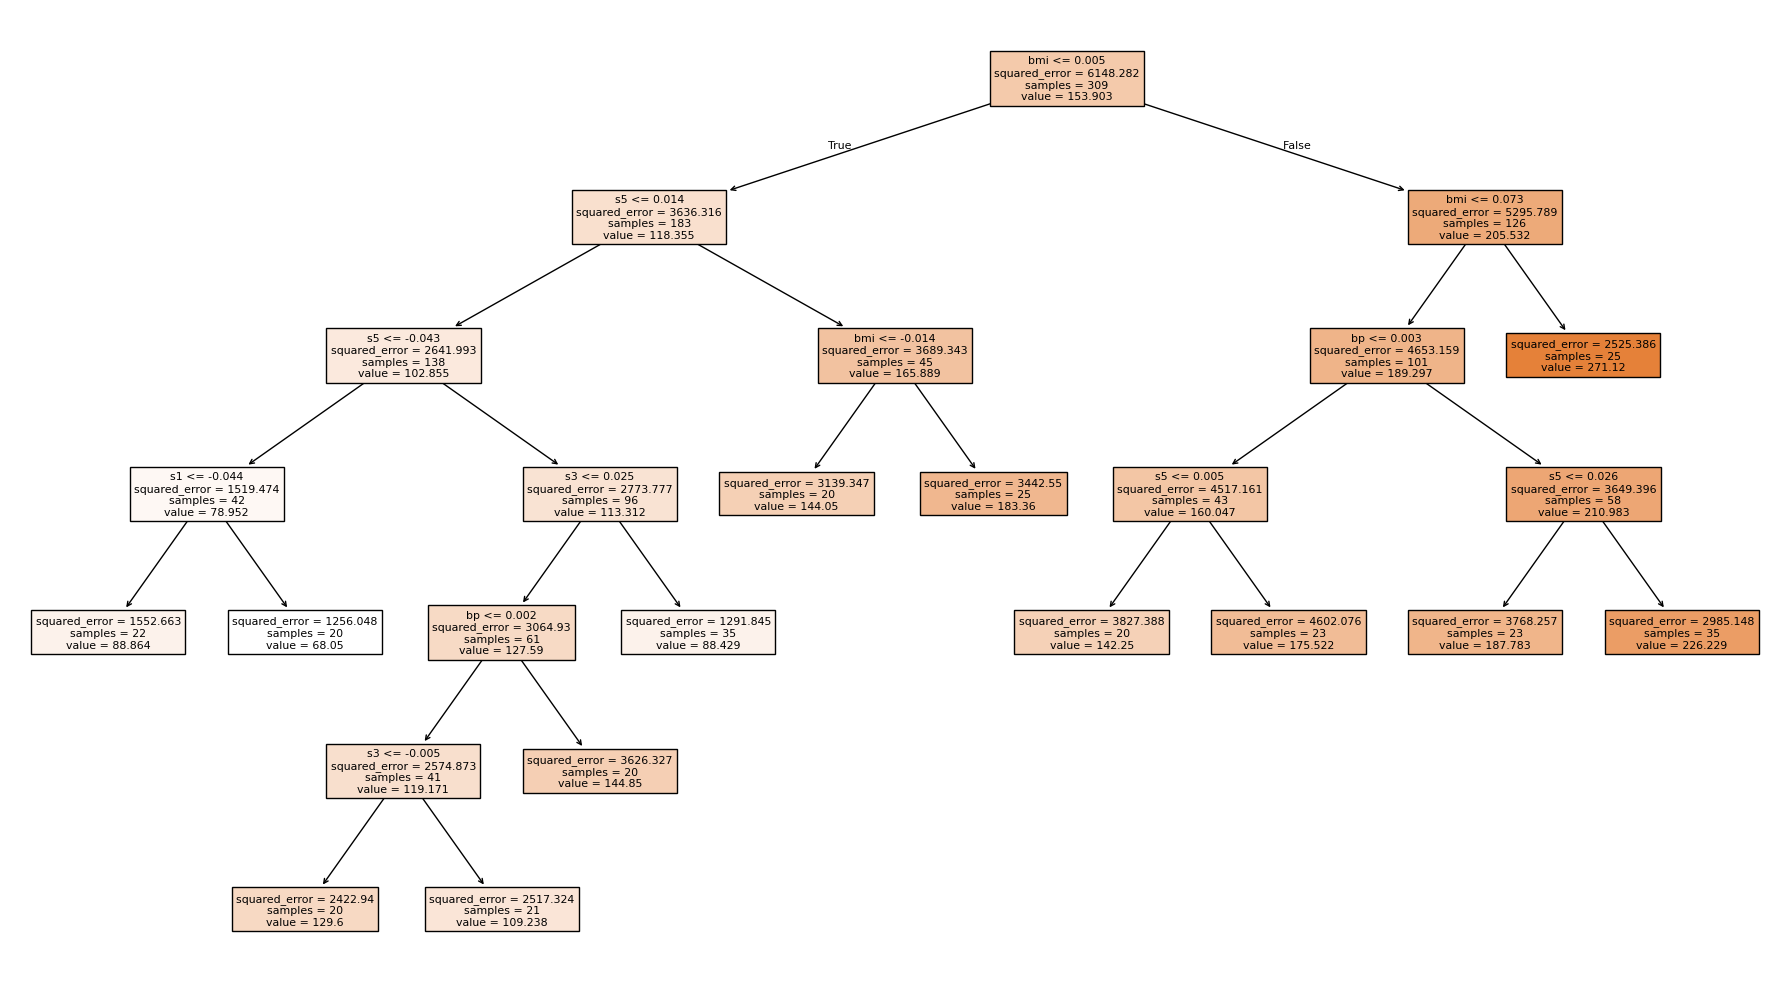

In [7]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 10))

plot_tree(
    model,
    feature_names=X.columns,
    filled=True
)

plt.tight_layout()

# # HYPERPARAMETER TUNING

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# Base model
regressor = DecisionTreeRegressor()

# Define parameter grid
param_grid = {
    "max_depth": [2, 3 ,4 , 5 ,6, 7,8, 9],
    "min_samples_split": [2, 3, 5, 7 , 10, 20],
    "min_samples_leaf": [1, 3 ,  5, 7 , 10, 20]
}

regressorCV = GridSearchCV(
    estimator=regressor,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_squared_error"
)


# Fit model
regressorCV.fit(X_train, y_train)

# Predictions
y_pred = regressorCV.predict(X_test)

# Evaluation metrics for regression
y_pred_train = regressorCV.predict(X_train)
print("r^2 train: ", r2_score(y_train, y_pred_train))
print("R2 score: ", r2_score(y_test, y_pred))
print("MSE: ", mean_squared_error(y_test, y_pred))

# Results DataFrame
res = pd.DataFrame(regressorCV.cv_results_)
print(res[["param_max_depth", "param_min_samples_split", "param_min_samples_leaf", "mean_test_score"]])

# Best parameters
print("Best Params: ", regressorCV.best_params_)


r^2 train:  0.5229417876314364
R2 score:  0.40581497124548527
MSE:  3207.593652721904
     param_max_depth  param_min_samples_split  param_min_samples_leaf  \
0                  2                        2                       1   
1                  2                        3                       1   
2                  2                        5                       1   
3                  2                        7                       1   
4                  2                       10                       1   
..               ...                      ...                     ...   
283                9                        3                      20   
284                9                        5                      20   
285                9                        7                      20   
286                9                       10                      20   
287                9                       20                      20   

     mean_test_score  
0           0.